In [ ]:
# Step 1: Read data and split train/test set
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('v1_cleaned_heart_disease_uci.csv')

# Basic preprocessing
df_processed = df.drop('id', axis=1).copy()
df_processed['target'] = (df_processed['num'] > 0).astype(int)
df_processed = df_processed.drop('num', axis=1)

# Encode categorical variables
categorical_columns = ['sex', 'cp', 'restecg']
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

df_processed = df_processed.drop(categorical_columns, axis=1)
X = df_processed.drop('target', axis=1)
y = df_processed['target']

print(f"Dataset shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Step 2: Feature engineering and select top importance features
X_enhanced = X.copy()

# Create interaction features
if all(col in X.columns for col in ['age', 'thalch']):
    X_enhanced['age_thalch_interaction'] = X['age'] * X['thalch'] / 1000

if all(col in X.columns for col in ['trestbps', 'chol']):
    X_enhanced['bp_chol_interaction'] = X['trestbps'] * X['chol'] / 10000

# Risk ratios
if all(col in X.columns for col in ['age', 'thalch']):
    X_enhanced['age_fitness_ratio'] = X['age'] / (X['thalch'] + 1)

if all(col in X.columns for col in ['oldpeak', 'thalch']):
    X_enhanced['stress_recovery_ratio'] = X['oldpeak'] / (X['thalch'] / 100 + 0.1)

# Normalized risk indicators
if 'age' in X.columns:
    X_enhanced['age_normalized'] = (X['age'] - 40) / 40

if 'chol' in X.columns:
    X_enhanced['chol_risk'] = np.where(X['chol'] > 240, (X['chol'] - 240) / 100, 0)

if 'trestbps' in X.columns:
    X_enhanced['bp_risk'] = np.where(X['trestbps'] > 140, (X['trestbps'] - 140) / 50, 0)

# Categorical combinations
if all(col in X.columns for col in ['cp_encoded', 'exang']):
    X_enhanced['cp_exang_risk'] = X['cp_encoded'] * 3 + X['exang'] * 2

if all(col in X.columns for col in ['sex_encoded', 'age']):
    X_enhanced['gender_age_risk'] = X['sex_encoded'] * (X['age'] > 55).astype(int)

# Select top importance features based on provided list
top_features = ['exang', 'cp_encoded', 'thalch', 'oldpeak', 'thal', 'sex_encoded', 
               'age', 'chol', 'trestbps', 'ca', 'slope']

# Add engineered features that exist
available_features = []
for feature in top_features:
    if feature in X_enhanced.columns:
        available_features.append(feature)

# Add some engineered features
engineered_to_add = ['age_thalch_interaction', 'age_fitness_ratio', 'stress_recovery_ratio', 
                    'chol_risk', 'bp_risk', 'cp_exang_risk']
for feature in engineered_to_add:
    if feature in X_enhanced.columns:
        available_features.append(feature)

X_selected = X_enhanced[available_features]

# Feature scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_selected), 
                       columns=X_selected.columns, 
                       index=X_selected.index)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Selected features: {len(available_features)}")

# Step 3: Build diverse neural networks
neural_networks = {}

# Deep Precision NN
neural_networks['Deep_Precision_NN'] = MLPClassifier(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    alpha=0.01,
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

# Wide Recall NN
neural_networks['Wide_Recall_NN'] = MLPClassifier(
    hidden_layer_sizes=(150, 150),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='constant',
    learning_rate_init=0.01,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

# Balanced NN
neural_networks['Balanced_NN'] = MLPClassifier(
    hidden_layer_sizes=(100, 80, 40),
    activation='tanh',
    solver='lbfgs',
    alpha=0.005,
    max_iter=500,
    random_state=42
)

# Dropout NN
neural_networks['Dropout_NN'] = MLPClassifier(
    hidden_layer_sizes=(120, 60),
    activation='relu',
    solver='adam',
    alpha=0.1,
    learning_rate='invscaling',
    power_t=0.5,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)

# Shallow Fast NN
neural_networks['Shallow_Fast_NN'] = MLPClassifier(
    hidden_layer_sizes=(80,),
    activation='logistic',
    solver='adam',
    alpha=0.01,
    learning_rate='adaptive',
    max_iter=300,
    random_state=42
)

print(f"Created {len(neural_networks)} neural network architectures")

# Step 4: Training with balanced ensemble method
# Apply SMOTE for balanced training
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"SMOTE applied: {X_train.shape[0]} → {X_train_balanced.shape[0]} samples")

# Train all neural networks
trained_networks = {}
network_performances = {}

for name, network in neural_networks.items():
    print(f"Training {name}...")
    
    # Train the network
    network.fit(X_train_balanced, y_train_balanced)
    trained_networks[name] = network
    
    # Evaluate performance
    y_pred = network.predict(X_test)
    y_proba = network.predict_proba(X_test)[:, 1]
    
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    network_performances[name] = {
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'accuracy': accuracy,
        'predictions': y_pred,
        'probabilities': y_proba
    }
    
    print(f"  Recall: {recall:.3f}, Precision: {precision:.3f}, F1: {f1:.3f}")

# Create weighted ensemble
f1_scores = [perf['f1'] for perf in network_performances.values()]
weights = np.array(f1_scores) / sum(f1_scores)

# Weighted probability averaging
ensemble_probabilities = np.zeros(len(X_test))
for i, (name, perf) in enumerate(network_performances.items()):
    ensemble_probabilities += weights[i] * perf['probabilities']

# Optimize threshold for best performance
thresholds = np.arange(0.05, 0.95, 0.01)
best_f1 = 0
best_threshold = 0.5
best_metrics = {}

for threshold in thresholds:
    ensemble_pred = (ensemble_probabilities >= threshold).astype(int)
    
    recall = recall_score(y_test, ensemble_pred)
    precision = precision_score(y_test, ensemble_pred)
    f1 = f1_score(y_test, ensemble_pred)
    accuracy = accuracy_score(y_test, ensemble_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_metrics = {
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'accuracy': accuracy,
            'threshold': threshold
        }

final_ensemble_pred = (ensemble_probabilities >= best_threshold).astype(int)

print("\nBest Ensemble Results:")
print(f"Threshold: {best_threshold:.3f}")
print(f"Recall: {best_metrics['recall']:.3f}")
print(f"Precision: {best_metrics['precision']:.3f}")
print(f"F1-Score: {best_metrics['f1']:.3f}")
print(f"Accuracy: {best_metrics['accuracy']:.3f}")

# Step 5: Classification report and confusion matrix
print("\nClassification Report:")
target_names = ['No Disease', 'Disease']
print(classification_report(y_test, final_ensemble_pred, target_names=target_names, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, final_ensemble_pred)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"              No Disease  Disease")
print(f"Actual No Disease    {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"       Disease       {cm[1,0]:3d}      {cm[1,1]:3d}")

tn, fp, fn, tp = cm.ravel()
print(f"\nDetailed Metrics:")
print(f"True Negatives:   {tn}")
print(f"False Positives:  {fp}")
print(f"False Negatives:  {fn}")
print(f"True Positives:   {tp}")

# Feature importance from correlation with target
feature_importance = abs(X_scaled.corrwith(y)).sort_values(ascending=False)
print("\nTop 10 Feature Importance:")
print(feature_importance.head(10))



Dataset shape: (920, 14)
Target distribution: {1: 509, 0: 411}
Training set: (736, 17)
Testing set: (184, 17)
Selected features: 17
Created 5 neural network architectures
SMOTE applied: 736 → 814 samples
Training Deep_Precision_NN...
  Recall: 0.833, Precision: 0.794, F1: 0.813
Training Wide_Recall_NN...
  Recall: 0.873, Precision: 0.824, F1: 0.848
Training Balanced_NN...
  Recall: 0.833, Precision: 0.794, F1: 0.813
Training Dropout_NN...
  Recall: 0.863, Precision: 0.822, F1: 0.842
Training Shallow_Fast_NN...
  Recall: 0.775, Precision: 0.790, F1: 0.782

Best Ensemble Results:
Threshold: 0.450
Recall: 0.892
Precision: 0.820
F1-Score: 0.854
Accuracy: 0.832

Classification Report:
              precision    recall  f1-score   support

  No Disease      0.849     0.756     0.800        82
     Disease      0.820     0.892     0.854       102

    accuracy                          0.832       184
   macro avg      0.835     0.824     0.827       184
weighted avg      0.833     0.832     0

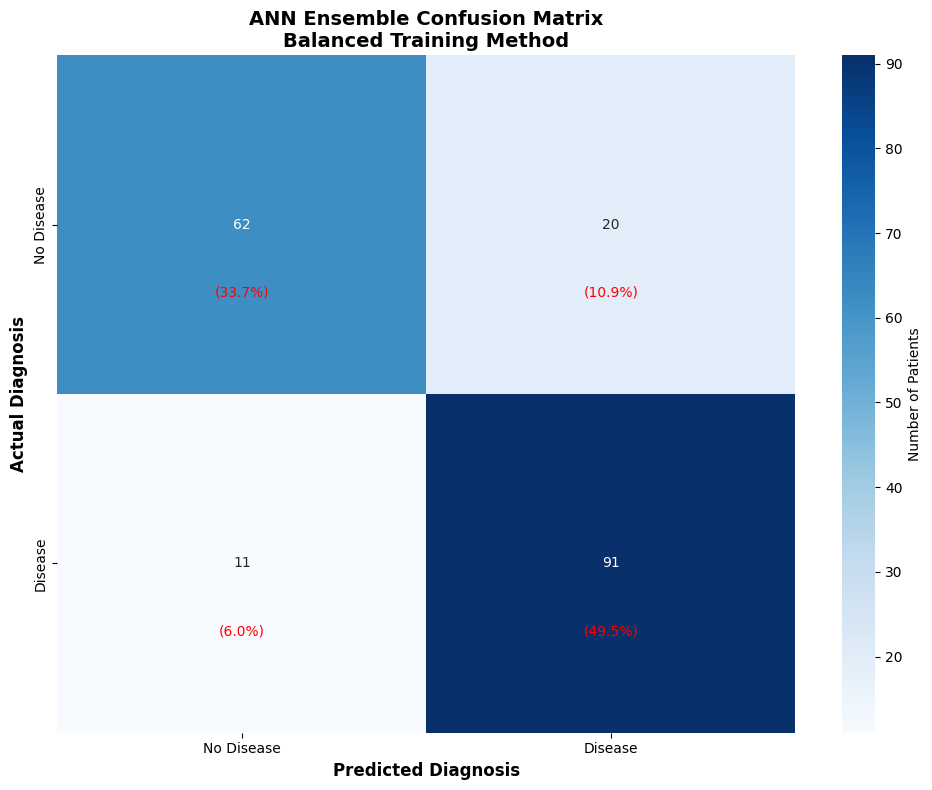

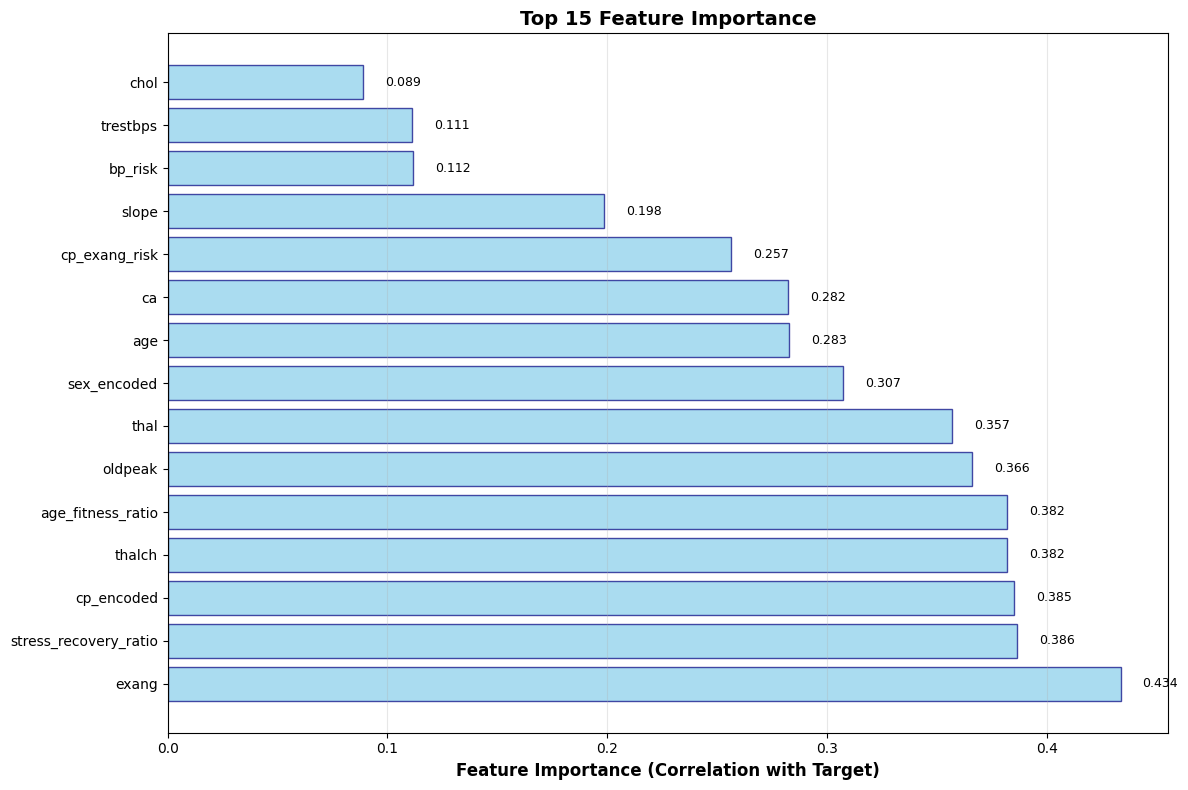

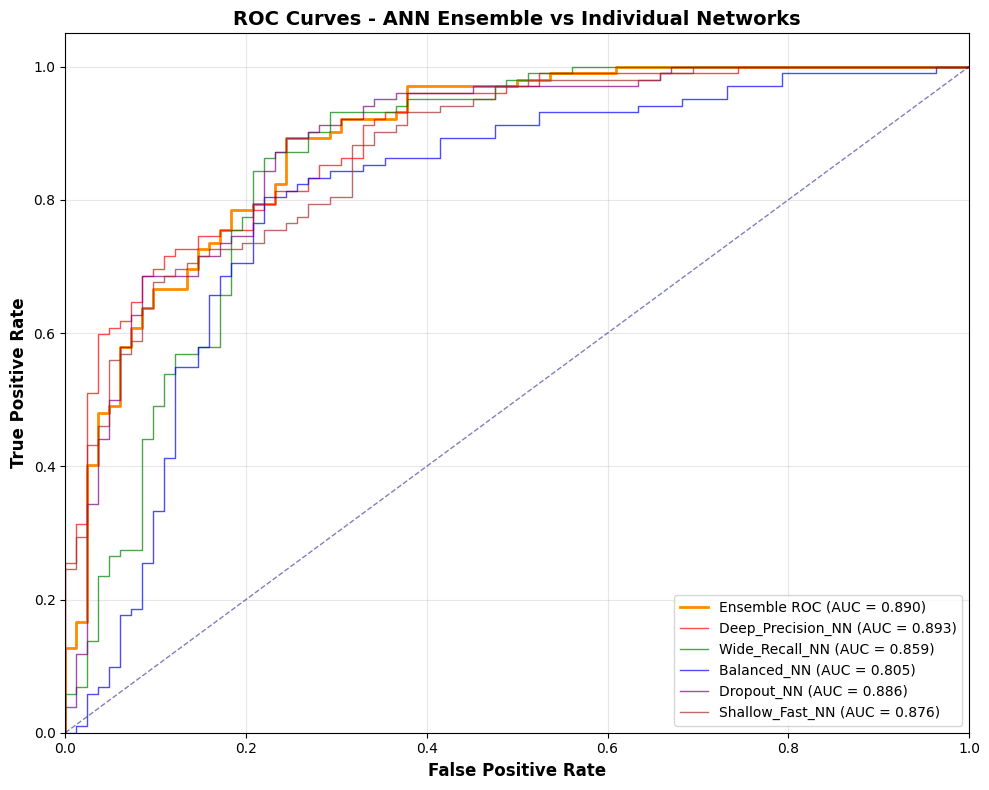

<Figure size 1400x1000 with 0 Axes>

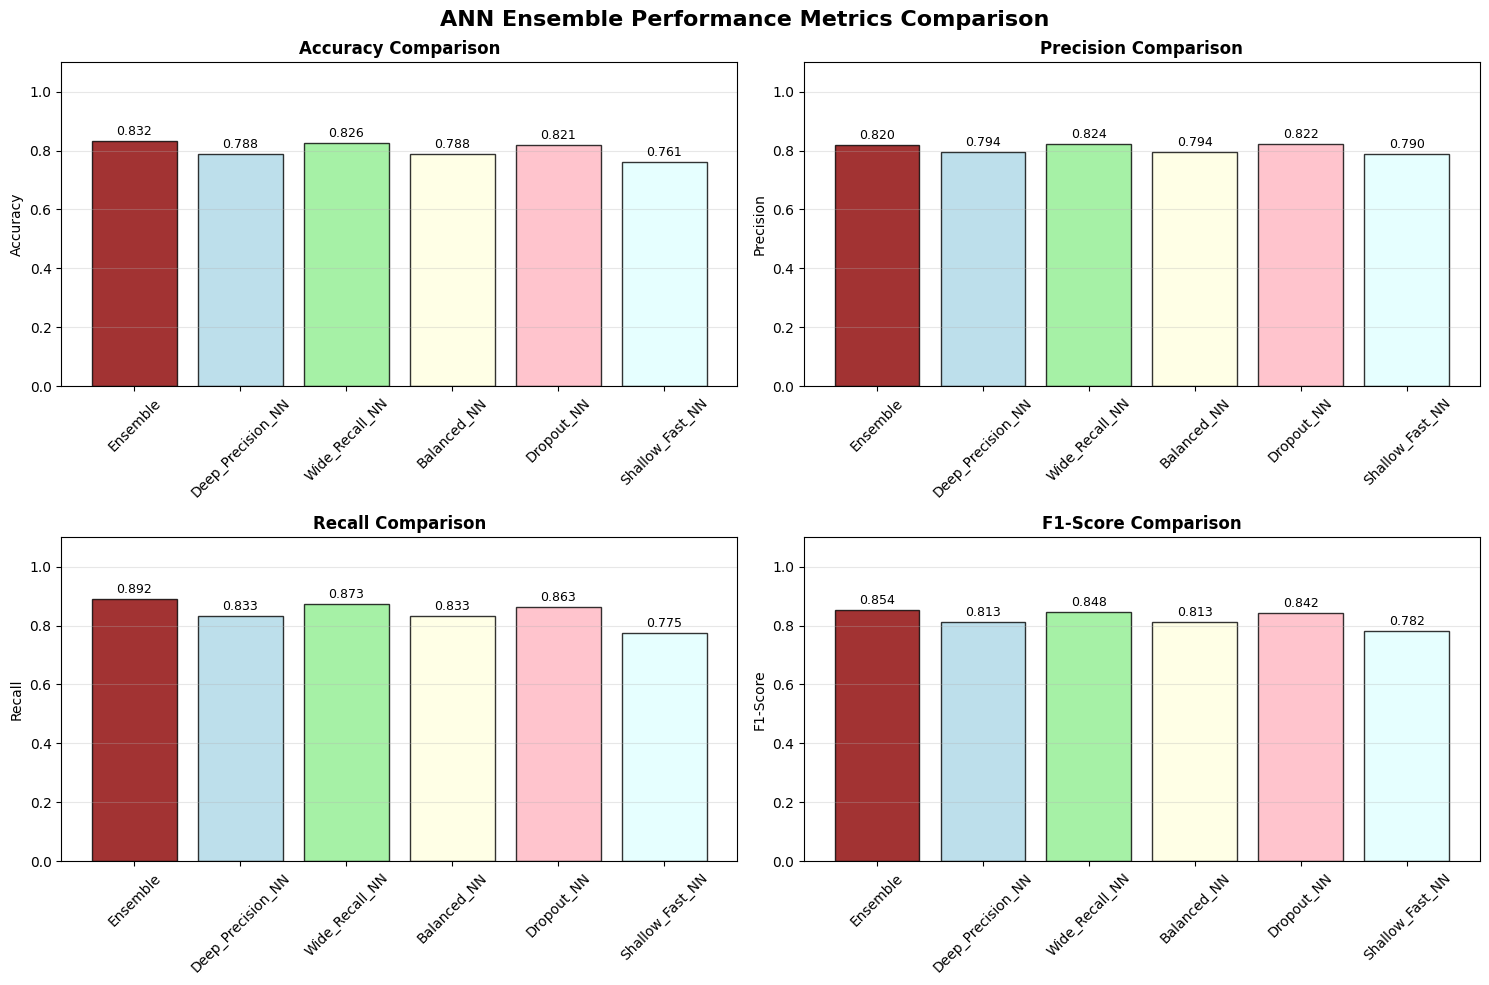


Cross-validation Results:
Deep_Precision_NN: 0.776 (+/- 0.076)
Wide_Recall_NN: 0.818 (+/- 0.098)
Balanced_NN: 0.798 (+/- 0.107)
Dropout_NN: 0.798 (+/- 0.094)
Shallow_Fast_NN: 0.786 (+/- 0.095)


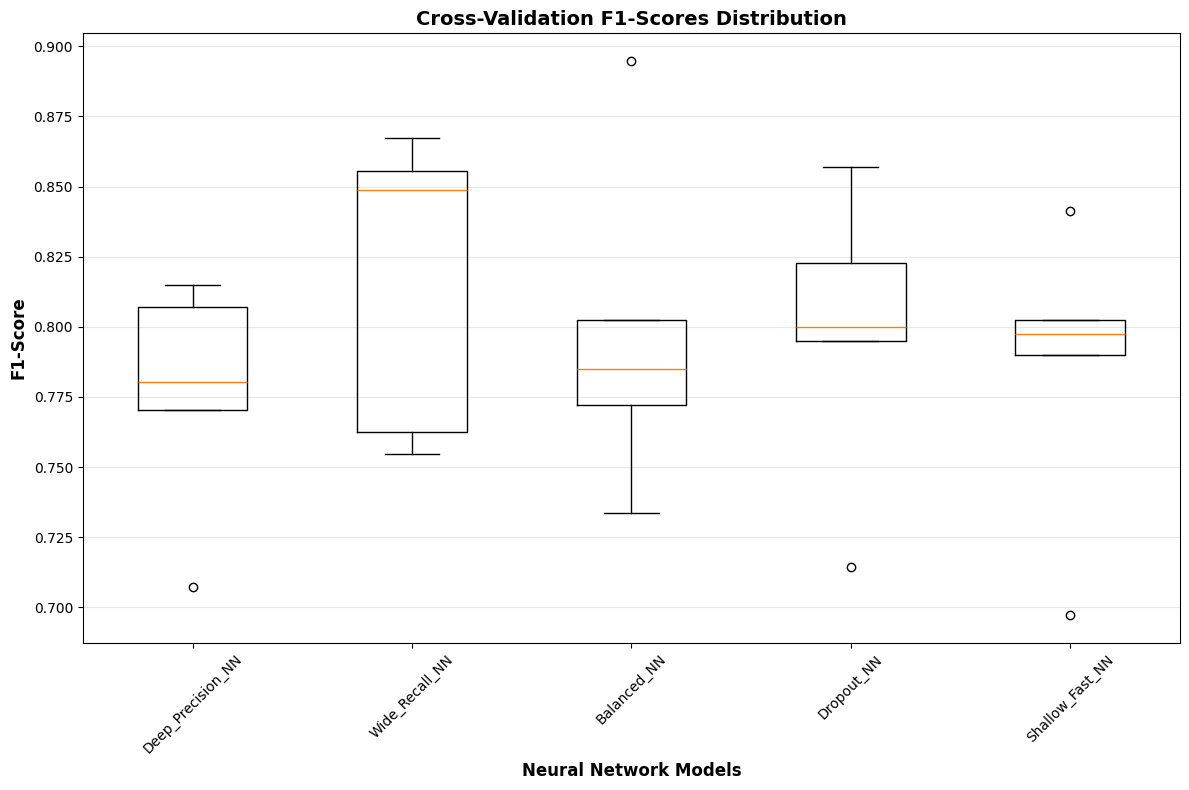


FINAL SUMMARY
Best Method: Balanced ANN Ensemble
Total Features: 17
Training Samples: 814 (SMOTE balanced)
Testing Samples: 184
Optimal Threshold: 0.450
Final Performance:
  Accuracy:  0.832
  Precision: 0.820
  Recall:    0.892
  F1-Score:  0.854
  AUC:       0.890


In [16]:
# Step 6: Visualizations

# 1. Confusion Matrix Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Number of Patients'})
plt.title('ANN Ensemble Confusion Matrix\nBalanced Training Method', fontsize=14, fontweight='bold')
plt.ylabel('Actual Diagnosis', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Diagnosis', fontsize=12, fontweight='bold')

total = cm.sum()
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / total * 100
        plt.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=10, color='red')
plt.tight_layout()
plt.show()

# 2. Feature Importance Visualization
plt.figure(figsize=(12, 8))
top_features_imp = feature_importance.head(15)
bars = plt.barh(range(len(top_features_imp)), top_features_imp.values, 
                color='skyblue', edgecolor='navy', alpha=0.7)
plt.yticks(range(len(top_features_imp)), top_features_imp.index)
plt.xlabel('Feature Importance (Correlation with Target)', fontsize=12, fontweight='bold')
plt.title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 3. ROC Curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, ensemble_probabilities)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Ensemble ROC (AUC = {roc_auc:.3f})')

# Individual network ROC curves
colors = ['red', 'green', 'blue', 'purple', 'brown']
for i, (name, perf) in enumerate(network_performances.items()):
    fpr_ind, tpr_ind, _ = roc_curve(y_test, perf['probabilities'])
    auc_ind = auc(fpr_ind, tpr_ind)
    plt.plot(fpr_ind, tpr_ind, color=colors[i], lw=1, alpha=0.7,
             label=f'{name} (AUC = {auc_ind:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - ANN Ensemble vs Individual Networks', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Performance Metrics Comparison
plt.figure(figsize=(14, 10))

# Prepare data for visualization
methods = ['Ensemble'] + list(network_performances.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Ensemble metrics
ensemble_metrics = [
    best_metrics['accuracy'],
    best_metrics['precision'], 
    best_metrics['recall'],
    best_metrics['f1']
]

# Individual network metrics
network_metrics = []
for name in network_performances.keys():
    perf = network_performances[name]
    network_metrics.append([perf['accuracy'], perf['precision'], perf['recall'], perf['f1']])

all_metrics = [ensemble_metrics] + network_metrics

# Create subplot for each metric
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

colors = ['darkred'] + ['lightblue', 'lightgreen', 'lightyellow', 'lightpink', 'lightcyan']

for i, metric in enumerate(metrics):
    values = [all_metrics[j][i] for j in range(len(methods))]
    bars = axes[i].bar(methods, values, color=colors, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric, fontsize=10)
    axes[i].set_ylim([0, 1.1])
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('ANN Ensemble Performance Metrics Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Cross-validation results
print("\nCross-validation Results:")
cv_scores = {}

for name, network in trained_networks.items():
    # Use original balanced training data for CV
    cv_score = cross_val_score(network, X_train_balanced, y_train_balanced, 
                              cv=5, scoring='f1', n_jobs=-1)
    cv_scores[name] = cv_score
    print(f"{name}: {cv_score.mean():.3f} (+/- {cv_score.std() * 2:.3f})")

# CV Visualization
plt.figure(figsize=(12, 8))
cv_data = []
cv_labels = []

for name, scores in cv_scores.items():
    cv_data.append(scores)
    cv_labels.append(name)

plt.boxplot(cv_data, labels=cv_labels)
plt.title('Cross-Validation F1-Scores Distribution', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.xlabel('Neural Network Models', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"Best Method: Balanced ANN Ensemble")
print(f"Total Features: {len(available_features)}")
print(f"Training Samples: {len(X_train_balanced)} (SMOTE balanced)")
print(f"Testing Samples: {len(X_test)}")
print(f"Optimal Threshold: {best_threshold:.3f}")
print(f"Final Performance:")
print(f"  Accuracy:  {best_metrics['accuracy']:.3f}")
print(f"  Precision: {best_metrics['precision']:.3f}")
print(f"  Recall:    {best_metrics['recall']:.3f}")
print(f"  F1-Score:  {best_metrics['f1']:.3f}")
print(f"  AUC:       {roc_auc:.3f}")